In [1]:
import simpy
import matplotlib.pyplot as plt
import random

class Stats:
    def __init__(self):
        self.arrived = 0
        self.served = 0
        self.rejected = 0
        self.busy_time = 0

class Object:
    def __init__(self):
        pass

    def handle_time(self):
        return 0 # apply some state in children, ex. longer serve time for a patient for some reason

class Patient(Object):
    def __init__(self):
        super().__init__() # later do some gen with small probability of implying time-wasting problems

    def handle_time(self):
        return 0 # for now do not imitate special cases, later return additional time

class Worker:
    def __init__(self, env, stats):
        self.env = env
        self.stats = stats
        self.locked = False

    def work(self, target):
        pass # implement in children, do target handle

    def lock(self):
        self.locked = True

    def unlock(self):
        self.locked = False

    def get_stats(self):
        return self.stats

class Doctor(Worker):
    def __init__(self, env, stats, mu_rate):
        super().__init__(env, stats)
        self.mu_rate = mu_rate

    def work(self, target):
        if self.locked:
            self.stats.rejected += 1
        else:
            self.lock()
            start_time = self.env.now
            service_time = random.expovariate(self.mu_rate)
            yield self.env.timeout(service_time + target.handle_time())
            self.unlock()
            self.stats.busy_time += (self.env.now - start_time)
            self.stats.served += 1

class StreamGenerator:
    def __init__(self, env, stats, worker):
        self.env = env
        self.stats = stats
        self.worker = worker

    def start(self):
        pass # start infinite generation with exp interval

class PatientStreamGenerator(StreamGenerator):
    def __init__(self, env, stats, worker, lambda_rate):
        super().__init__(env, stats, worker)
        self.lambda_rate = lambda_rate

    def start(self):
        while True:
            next_arrival_time = random.expovariate(self.lambda_rate)
            yield self.env.timeout(next_arrival_time)

            self.stats.arrived += 1
            self.env.process(self.worker.work(Patient()))

In [2]:
import models

def run_simulation(lambda_rate, mu_rate, sim_time):
    env = simpy.Environment()
    stat = models.Stats()
    doctor = models.Doctor(env, stat, mu_rate)
    generator = models.PatientStreamGenerator(env, stat, doctor, lambda_rate)

    env.process(generator.start())
    env.run(until=sim_time)

    p_loss_exp = stat.rejected / stat.arrived if stat.arrived > 0 else 0
    utilization = stat.busy_time / sim_time if sim_time > 0 else 0

    print(f"Всего: {stat.arrived}, Обслужено: {stat.served}, Отказано: {stat.rejected}")

    return stat, p_loss_exp, utilization

def theoretical_erlang(lambda_rate, mu_rate):
    rho = lambda_rate / mu_rate
    p_loss = rho / (1 + rho)
    return p_loss

Mu: 5.0, Lambda: 2.0
Всего: 1912, Обслужено: 1394, Отказано: 518
Lambda: 2.0 P_отк: 0.2709 P_отк_теор: 0.2857 Загрузка: 0.2773


Mu: 5.0, Lambda: 4.0
Всего: 4005, Обслужено: 2212, Отказано: 1792
Lambda: 4.0 P_отк: 0.4474 P_отк_теор: 0.4444 Загрузка: 0.4423


Mu: 5.0, Lambda: 6.0
Всего: 5886, Обслужено: 2717, Отказано: 3169
Lambda: 6.0 P_отк: 0.5384 P_отк_теор: 0.5455 Загрузка: 0.5339


Mu: 5.0, Lambda: 8.0
Всего: 7878, Обслужено: 3036, Отказано: 4841
Lambda: 8.0 P_отк: 0.6145 P_отк_теор: 0.6154 Загрузка: 0.6113


Mu: 5.0, Lambda: 10.0
Всего: 9866, Обслужено: 3328, Отказано: 6537
Lambda: 10.0 P_отк: 0.6626 P_отк_теор: 0.6667 Загрузка: 0.6606




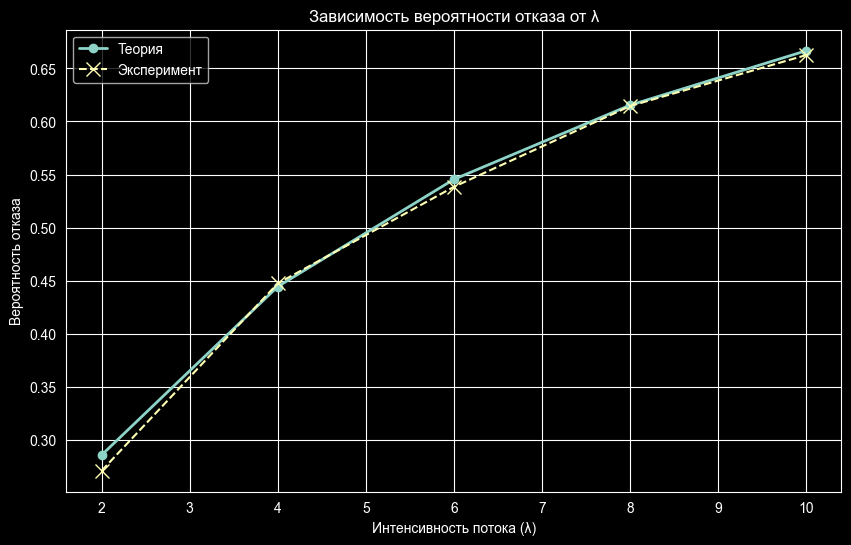

In [3]:
SIM_TIME = 1000
MU = 5.0
lambdas = [2.0, 4.0, 6.0, 8.0, 10.0]

results = []
theory_results = []

for LAMBDA in lambdas:
    print(f"Mu: {MU}, Lambda: {LAMBDA}")
    stats, p_exp, util = run_simulation(LAMBDA, MU, SIM_TIME)
    p_theory = theoretical_erlang(LAMBDA, MU)
    results.append(p_exp)
    theory_results.append(p_theory)
    print(f"Lambda: {LAMBDA:} P_отк: {p_exp:.4f} P_отк_теор: {p_theory:.4f} Загрузка: {util:.4f}")
    print("\n")

plt.figure(figsize=(10, 6))
plt.plot(lambdas, theory_results, 'o-', label='Теория', linewidth=2)
plt.plot(lambdas, results, 'x--', label='Эксперимент', markersize=10)
plt.xlabel('Интенсивность потока (λ)')
plt.ylabel('Вероятность отказа')
plt.title('Зависимость вероятности отказа от λ')
plt.grid(True)
plt.legend()
plt.savefig('lab1_graph.png')
plt.show()